# Practical 3: Convolutional Neural Network (CNN)
## Fashion MNIST Clothing Classifier

**Aim:** Classify fashion clothing images into 10 categories using CNN  
**Dataset:** Fashion MNIST (built-in from Keras — no download needed!)

### 10 Clothing Categories:
| Label | Class |
|-------|-------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

# Class names for labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


TensorFlow version: 2.21.0


## Step 2: Load Fashion MNIST Dataset

In [2]:
# Load dataset (downloads automatically)
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images    :", X_test.shape)
print("Test labels    :", y_test.shape)
print("\nEach image is 28x28 pixels, grayscale")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images    : (10000, 28, 28)
Test labels    : (10000,)

Each image is 28x28 pixels, grayscale


## Step 3: Visualize Sample Images

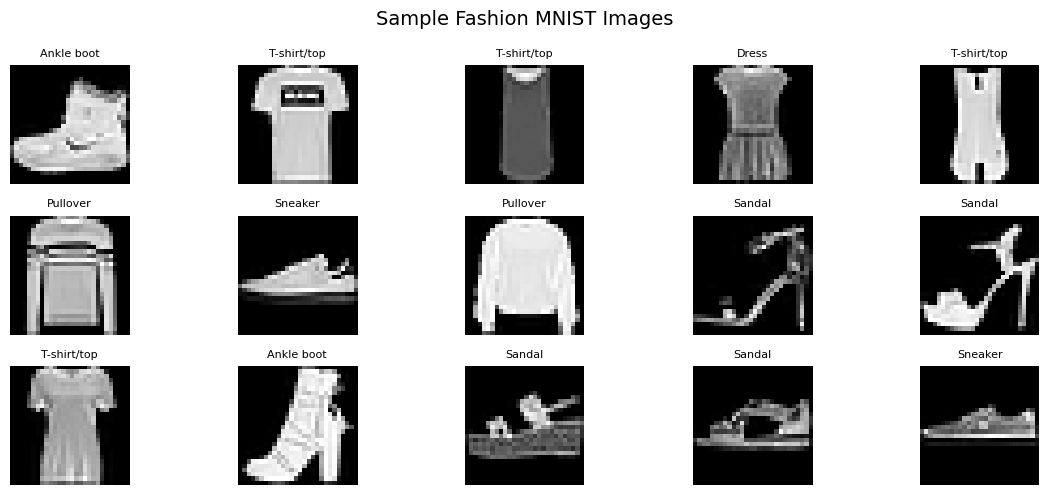

In [3]:
# Show first 15 images from training set
plt.figure(figsize=(12, 5))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis('off')

plt.suptitle("Sample Fashion MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()


## Step 4: Preprocess the Data

In [4]:
# Normalize pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Reshape for CNN: (samples, height, width, channels)
# channels=1 because grayscale
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print("After reshaping:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Pixel value range: 0 to", X_train.max())


After reshaping:
X_train shape: (60000, 28, 28, 1)
X_test shape : (10000, 28, 28, 1)
Pixel value range: 0 to 1.0


## Step 5: Build the CNN Model

In [5]:
# Build CNN model
model = keras.Sequential([
    # --- Convolutional Block 1 ---
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    # Conv2D: 32 filters, 3x3 size — detects basic patterns
    layers.MaxPooling2D(2, 2),
    # MaxPooling: reduces size by half, keeps important info

    # --- Convolutional Block 2 ---
    layers.Conv2D(64, (3,3), activation='relu'),
    # 64 filters — detects complex patterns
    layers.MaxPooling2D(2, 2),

    # --- Fully Connected Part ---
    layers.Flatten(),                          # Convert 2D to 1D
    layers.Dense(128, activation='relu'),      # Hidden layer
    layers.Dropout(0.5),                       # Prevent overfitting
    layers.Dense(10, activation='softmax')     # Output: 10 classes
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # For multi-class
              metrics=['accuracy'])

model.summary()


C:\Users\Pratham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the Model

In [6]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("\nTraining complete!")


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.7727 - loss: 0.6205 - val_accuracy: 0.8567 - val_loss: 0.3857
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8514 - loss: 0.4124 - val_accuracy: 0.8767 - val_loss: 0.3258
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.8734 - loss: 0.3540 - val_accuracy: 0.8780 - val_loss: 0.3130
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.8836 - loss: 0.3224 - val_accuracy: 0.8960 - val_loss: 0.2810
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8902 - loss: 0.2993 - val_accuracy: 0.9012 - val_loss: 0.2693
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8980 - loss: 0.2850 - val_accuracy: 0.8998 - val_loss: 0.2694
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9032 - loss: 0.2634 - val_accuracy: 0.9012 - val_loss: 0.2669
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9097 - loss: 0.2452 - 

## Step 7: Evaluate the Model

In [7]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test Results:")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")


Test Results:
  Test Loss     : 0.2476
  Test Accuracy : 90.96%


## Step 8: Plot Training History

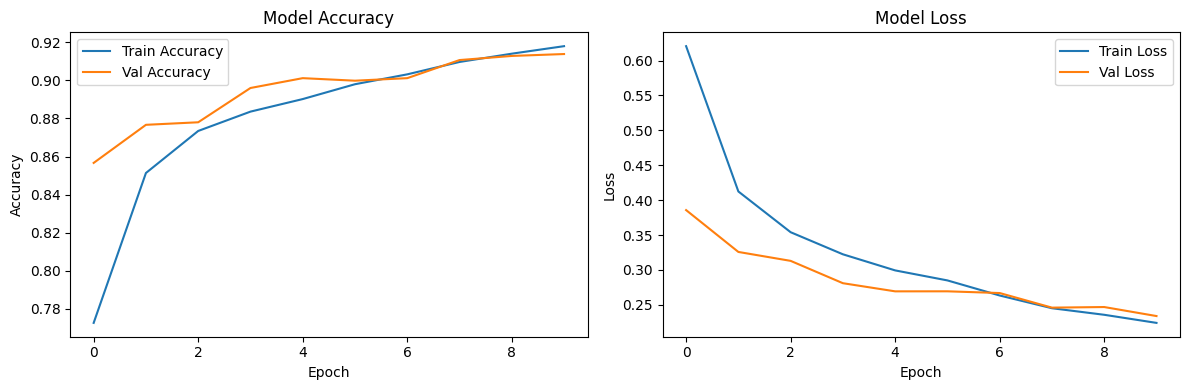

In [8]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Step 9: Predict on Test Images

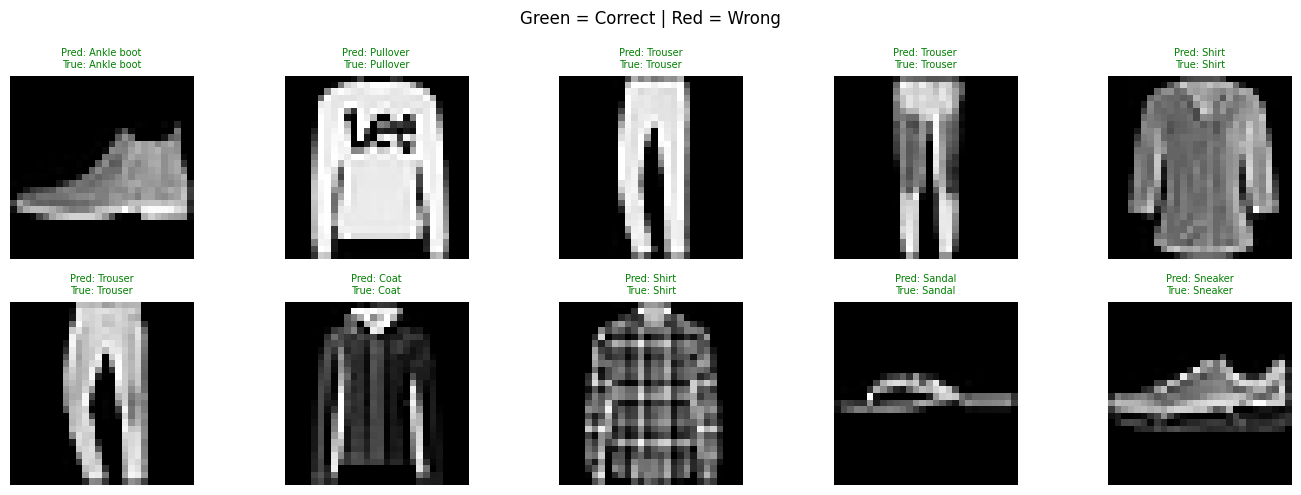

In [9]:
# Make predictions on test images
predictions = model.predict(X_test, verbose=0)

# Show 10 predictions with actual images
plt.figure(figsize=(14, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    
    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i]]
    
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", fontsize=7, color=color)
    plt.axis('off')

plt.suptitle("Green = Correct | Red = Wrong", fontsize=12)
plt.tight_layout()
plt.show()


## Step 10: Confusion Matrix

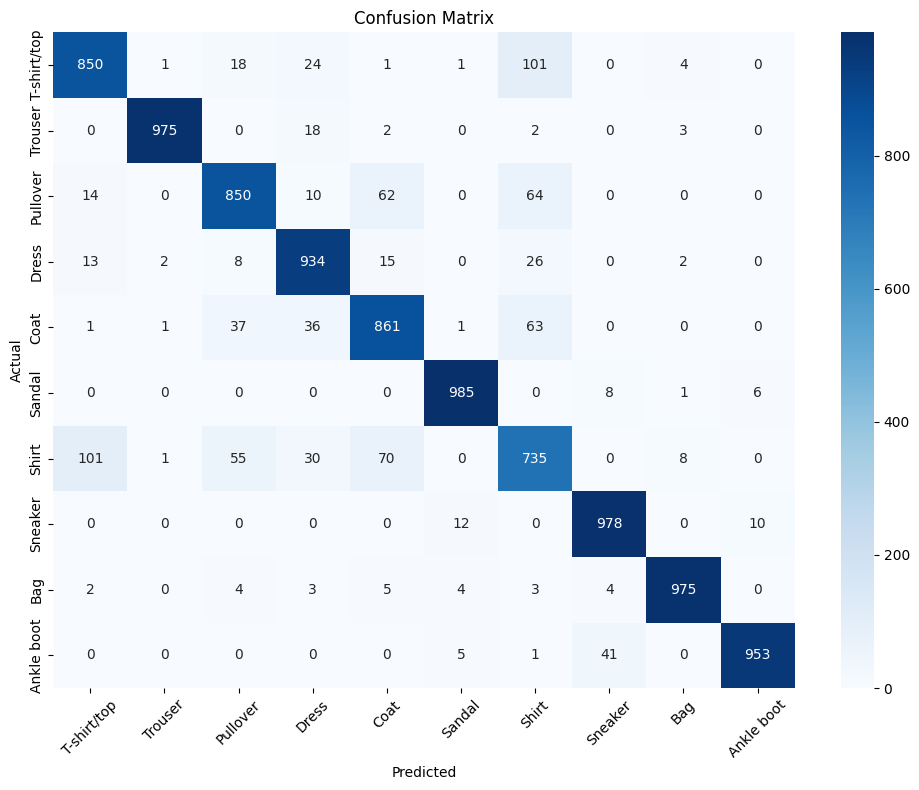


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.85      0.86      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.87      0.85      0.86      1000
       Dress       0.89      0.93      0.91      1000
        Coat       0.85      0.86      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.74      0.73      0.74      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predicted class labels
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


## Conclusion

- We built a **CNN** to classify 10 types of fashion clothing.
- **Conv2D** layers detect patterns (edges, shapes, textures) in images.
- **MaxPooling** reduces image size while keeping important features.
- **Softmax** output gives probability for each of the 10 classes.
- **Sparse Categorical Cross-Entropy** is used for multi-class classification.
- CNN achieves much better accuracy than a simple Dense network on image data!
